# 01 - Exploratory Data Analysis

**Proyecto:** `mining-analytics-ml-pipeline`

Este notebook realiza un análisis exploratorio inicial del dataset sintético de equipos mineros. El objetivo es entender el comportamiento de las variables operativas y detectar señales asociadas al riesgo de falla en los próximos 7 días.

El análisis está pensado para un caso de uso de **analytics industrial y mantenimiento predictivo en minería**.

## 1. Importación de librerías

Usaremos:

- `pandas` para leer y analizar datos.
- `numpy` para operaciones numéricas básicas.
- `matplotlib` para gráficos.
- `pathlib` para manejar rutas de archivos de forma ordenada.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Mostrar todas las columnas cuando imprimimos un DataFrame
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

## 2. Carga de datos

El dataset se encuentra en `data/raw/mining_equipment_data.csv`.

La siguiente lógica permite ejecutar el notebook desde la carpeta raíz del proyecto o desde la carpeta `notebooks`.

In [2]:
# Detectar la raíz del proyecto de forma simple
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "mining_equipment_data.csv"

# Validación básica para evitar errores silenciosos
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully from: {DATA_PATH}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully from: /mnt/data/mining-analytics-ml-pipeline/data/raw/mining_equipment_data.csv
Rows: 10,000
Columns: 13


## 3. Vista inicial del dataset

Primero revisamos las primeras filas, los tipos de datos y la estructura general.

In [3]:
df.head()

,equipment_id,equipment_type,operation_hours,temperature_celsius,vibration_mm_s,pressure_bar,current_amp,load_percentage,maintenance_days_since_last,failure_history_count,environment_dust_level,shift,failure_next_7_days
0,CRU-00001,crusher,1499.40,89.24,8.11,8.06,618.20,87.84,40,2,medium,day,1
1,CON-00002,conveyor_belt,6944.70,70.45,2.17,4.82,214.09,81.03,38,1,low,day,0
2,MIL-00003,mill,5297.20,78.02,7.09,6.27,585.89,89.54,41,2,high,night,1
3,CRU-00004,crusher,4688.10,89.32,8.65,7.25,526.23,83.12,89,1,medium,day,1
4,TRU-00005,truck,5530.20,82.87,6.98,7.52,467.35,72.34,37,1,low,night,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   equipment_id                 10000 non-null  object 
 1   equipment_type               10000 non-null  object 
 2   operation_hours              10000 non-null  float64
 3   temperature_celsius          10000 non-null  float64
 4   vibration_mm_s               10000 non-null  float64
 5   pressure_bar                 10000 non-null  float64
 6   current_amp                  10000 non-null  float64
 7   load_percentage              10000 non-null  float64
 8   maintenance_days_since_last  10000 non-null  int64  
 9   failure_history_count        10000 non-null  int64  
 10  environment_dust_level       10000 non-null  object 
 11  shift                        10000 non-null  object 
 12  failure_next_7_days          10000 non-null  int64  
dtypes: float64(6), in

## 4. Validación rápida de calidad de datos

Antes de analizar, revisamos si existen valores nulos o registros duplicados.

In [5]:
# Valores nulos por columna
null_summary = df.isnull().sum().sort_values(ascending=False)
null_summary

equipment_id                   0
equipment_type                 0
operation_hours                0
temperature_celsius            0
vibration_mm_s                 0
pressure_bar                   0
current_amp                    0
load_percentage                0
maintenance_days_since_last    0
failure_history_count          0
environment_dust_level         0
shift                          0
failure_next_7_days            0
dtype: int64

In [6]:
# Conteo de filas duplicadas
duplicated_rows = df.duplicated().sum()
print(f"Duplicated rows: {duplicated_rows}")

Duplicated rows: 0


## 5. Estadísticas descriptivas

Las estadísticas descriptivas permiten entender rangos, promedios, dispersión y posibles valores extremos.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
operation_hours,10000.00,4513.61,2025.96,516.80,3029.68,4222.20,5649.20,18544.60
temperature_celsius,10000.00,76.31,11.89,35.00,68.13,76.91,84.78,118.82
vibration_mm_s,10000.00,6.20,1.85,0.50,4.89,6.18,7.49,13.52
pressure_bar,10000.00,6.64,2.17,1.00,5.12,6.60,8.07,14.06
current_amp,10000.00,405.99,122.72,80.00,302.66,416.38,504.55,746.34
load_percentage,10000.00,74.47,11.08,34.13,66.88,74.36,82.03,100.00
maintenance_days_since_last,10000.00,53.77,31.15,1.00,31.00,48.00,71.00,240.00
failure_history_count,10000.00,1.10,1.05,0.00,0.00,1.00,2.00,7.00
failure_next_7_days,10000.00,0.18,0.38,0.00,0.00,0.00,0.00,1.00


In [8]:
# Resumen para variables categóricas
df.describe(include="object").T

,count,unique,top,freq
equipment_id,10000,10000,CRU-00001,1
equipment_type,10000,5,truck,2545
environment_dust_level,10000,3,medium,4535
shift,10000,2,day,5523


## 6. Distribución de la variable objetivo

La variable objetivo es `failure_next_7_days`.

- `0`: no se espera falla en los próximos 7 días.
- `1`: se espera falla en los próximos 7 días.

In [9]:
failure_distribution = (
    df["failure_next_7_days"]
    .value_counts()
    .sort_index()
    .rename(index={0: "No failure", 1: "Failure"})
)

failure_rate = df["failure_next_7_days"].mean()

print(f"Failure rate: {failure_rate:.2%}")
failure_distribution

Failure rate: 17.95%


failure_next_7_days
No failure    8205
Failure       1795
Name: count, dtype: int64

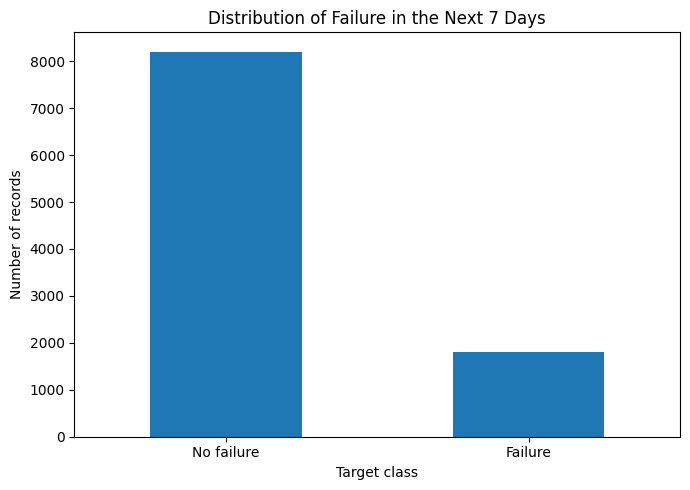

In [10]:
plt.figure(figsize=(7, 5))
failure_distribution.plot(kind="bar")
plt.title("Distribution of Failure in the Next 7 Days")
plt.xlabel("Target class")
plt.ylabel("Number of records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Promedio de temperatura por tipo de equipo

La temperatura es una variable crítica en equipos industriales porque puede estar asociada a sobrecarga, fricción, deficiencias de lubricación, problemas eléctricos o condiciones operativas exigentes.

In [11]:
avg_temperature_by_equipment = (
    df.groupby("equipment_type")["temperature_celsius"]
    .mean()
    .sort_values(ascending=False)
)

avg_temperature_by_equipment

equipment_type
crusher         86.40
mill            82.60
truck           79.47
pump            71.42
conveyor_belt   62.88
Name: temperature_celsius, dtype: float64

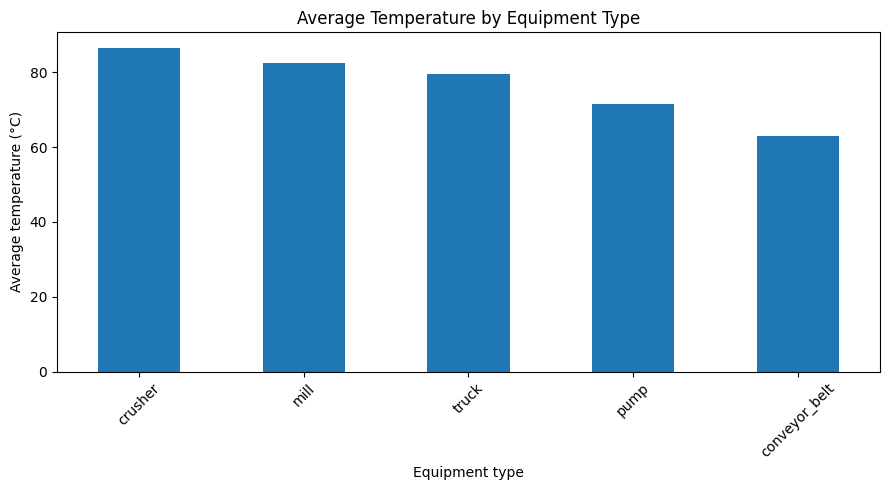

In [12]:
plt.figure(figsize=(9, 5))
avg_temperature_by_equipment.plot(kind="bar")
plt.title("Average Temperature by Equipment Type")
plt.xlabel("Equipment type")
plt.ylabel("Average temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Promedio de vibración por tipo de equipo

La vibración es una de las señales más usadas en mantenimiento predictivo. Un incremento puede estar relacionado con desbalance, desalineación, soltura mecánica, desgaste de rodamientos u otras condiciones anómalas.

In [13]:
avg_vibration_by_equipment = (
    df.groupby("equipment_type")["vibration_mm_s"]
    .mean()
    .sort_values(ascending=False)
)

avg_vibration_by_equipment

equipment_type
crusher         7.79
mill            7.06
truck           6.30
pump            5.35
conveyor_belt   4.77
Name: vibration_mm_s, dtype: float64

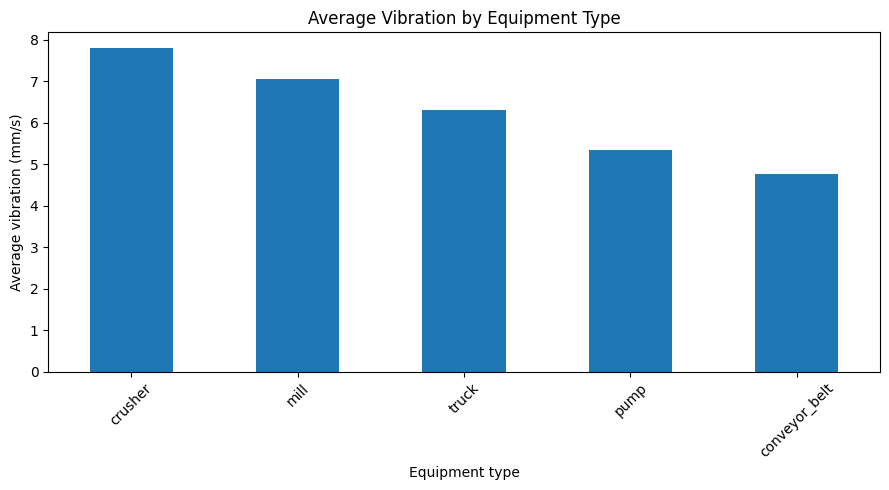

In [14]:
plt.figure(figsize=(9, 5))
avg_vibration_by_equipment.plot(kind="bar")
plt.title("Average Vibration by Equipment Type")
plt.xlabel("Equipment type")
plt.ylabel("Average vibration (mm/s)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Relación entre días desde el último mantenimiento y falla

Analizamos si los equipos con falla tienen, en promedio, más días desde su último mantenimiento.

In [15]:
maintenance_vs_failure = (
    df.groupby("failure_next_7_days")["maintenance_days_since_last"]
    .agg(["count", "mean", "median", "min", "max"])
    .rename(index={0: "No failure", 1: "Failure"})
)

maintenance_vs_failure

,count,mean,median,min,max
failure_next_7_days,,,,,
No failure,8205,50.95,45.00,1,240
Failure,1795,66.67,61.00,1,240


<Figure size 700x500 with 0 Axes>

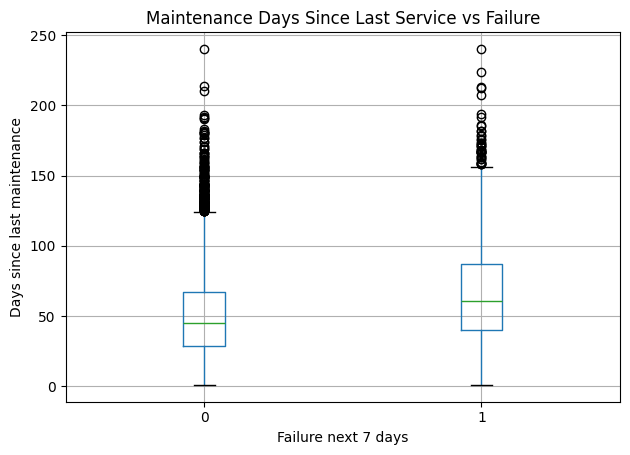

In [16]:
plt.figure(figsize=(7, 5))
df.boxplot(column="maintenance_days_since_last", by="failure_next_7_days")
plt.title("Maintenance Days Since Last Service vs Failure")
plt.suptitle("")
plt.xlabel("Failure next 7 days")
plt.ylabel("Days since last maintenance")
plt.tight_layout()
plt.show()

## 10. Relación entre vibración y falla

Comparamos la vibración promedio de los equipos con y sin falla esperada.

In [17]:
vibration_vs_failure = (
    df.groupby("failure_next_7_days")["vibration_mm_s"]
    .agg(["count", "mean", "median", "min", "max"])
    .rename(index={0: "No failure", 1: "Failure"})
)

vibration_vs_failure

,count,mean,median,min,max
failure_next_7_days,,,,,
No failure,8205,5.95,5.93,0.50,11.83
Failure,1795,7.35,7.40,2.17,13.52


<Figure size 700x500 with 0 Axes>

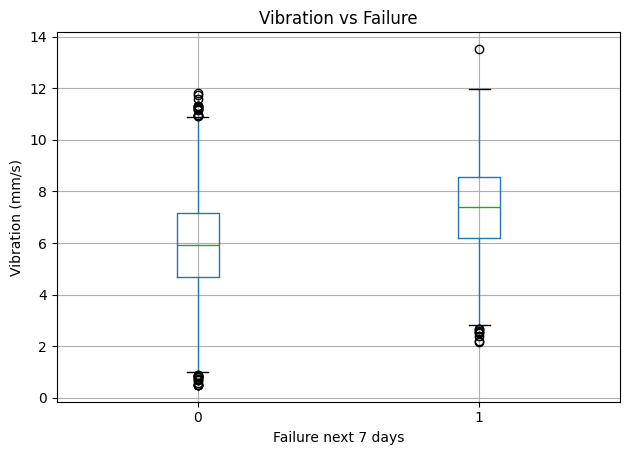

In [18]:
plt.figure(figsize=(7, 5))
df.boxplot(column="vibration_mm_s", by="failure_next_7_days")
plt.title("Vibration vs Failure")
plt.suptitle("")
plt.xlabel("Failure next 7 days")
plt.ylabel("Vibration (mm/s)")
plt.tight_layout()
plt.show()

## 11. Tasa de falla por tipo de equipo

Esta vista ayuda a priorizar familias de equipos con mayor criticidad operativa.

In [19]:
failure_rate_by_equipment = (
    df.groupby("equipment_type")
    .agg(
        records=("equipment_id", "count"),
        avg_temperature=("temperature_celsius", "mean"),
        avg_vibration=("vibration_mm_s", "mean"),
        avg_operation_hours=("operation_hours", "mean"),
        failure_rate=("failure_next_7_days", "mean"),
    )
    .sort_values("failure_rate", ascending=False)
)

failure_rate_by_equipment

,records,avg_temperature,avg_vibration,avg_operation_hours,failure_rate
equipment_type,,,,,
crusher,1797,86.40,7.79,4550.25,0.34
mill,1660,82.60,7.06,4464.15,0.25
truck,2545,79.47,6.30,4443.71,0.17
pump,1999,71.42,5.35,4520.99,0.11
conveyor_belt,1999,62.88,4.77,4603.34,0.05


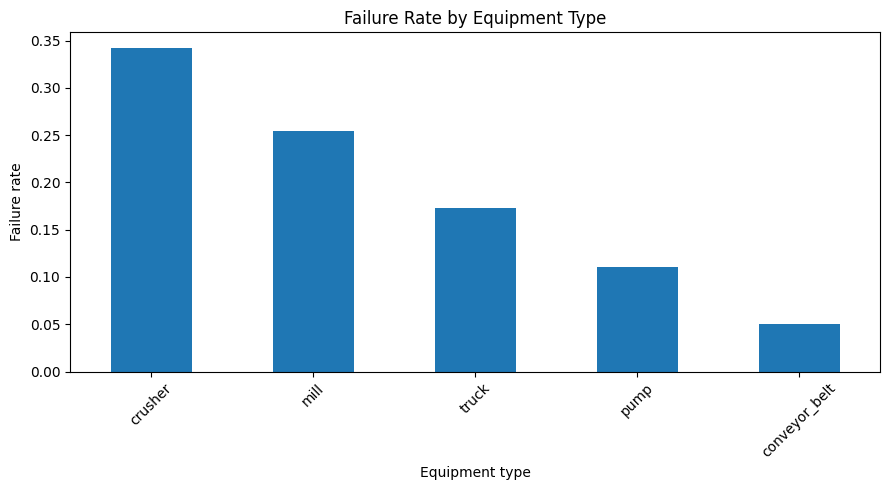

In [20]:
plt.figure(figsize=(9, 5))
failure_rate_by_equipment["failure_rate"].plot(kind="bar")
plt.title("Failure Rate by Equipment Type")
plt.xlabel("Equipment type")
plt.ylabel("Failure rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 12. Tasa de falla por nivel de polvo ambiental

El polvo puede afectar componentes mecánicos, eléctricos y de refrigeración. Por eso se analiza si el ambiente tiene relación con el riesgo de falla.

In [21]:
failure_rate_by_dust = (
    df.groupby("environment_dust_level")["failure_next_7_days"]
    .mean()
    .sort_values(ascending=False)
)

failure_rate_by_dust

environment_dust_level
high     0.23
medium   0.17
low      0.15
Name: failure_next_7_days, dtype: float64

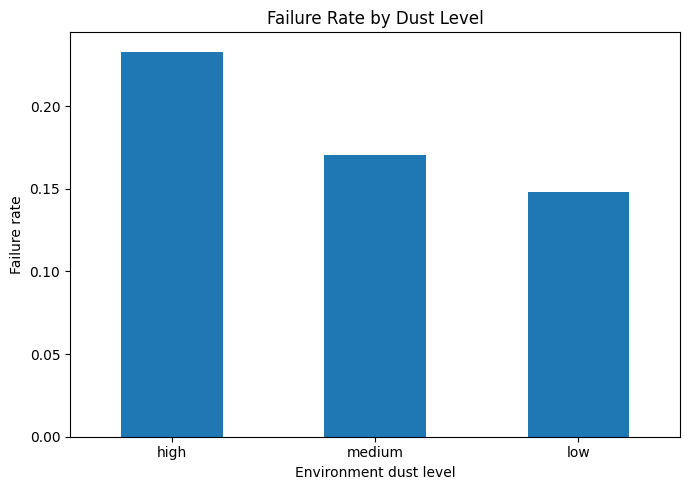

In [22]:
plt.figure(figsize=(7, 5))
failure_rate_by_dust.plot(kind="bar")
plt.title("Failure Rate by Dust Level")
plt.xlabel("Environment dust level")
plt.ylabel("Failure rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 13. Conclusiones de negocio e insights accionables

1. **Los equipos tipo `crusher` presentan la mayor tasa de falla simulada.** También muestran los promedios más altos de temperatura y vibración. Para mantenimiento predictivo, estos equipos deberían tener mayor prioridad en inspecciones por vibración, termografía y revisión de condiciones de carga.

2. **Los registros con falla tienen mayor vibración promedio que los registros sin falla.** Esto refuerza la importancia de monitorear vibración como una señal temprana de degradación mecánica. En operación minera, esta variable puede apoyar alertas preventivas antes de una parada no planificada.

3. **Los equipos con falla tienen más días promedio desde el último mantenimiento.** Esto sugiere que el tiempo desde la última intervención puede funcionar como una variable útil para priorizar órdenes de trabajo preventivas.

4. **El nivel de polvo alto se asocia con mayor tasa de falla.** En un entorno minero, esto puede justificar acciones como limpieza programada, revisión de sellos, protección de tableros, control de contaminación y mejoras en rutinas de inspección.

5. **La combinación de temperatura, vibración, historial de fallas y horas de operación permite construir un modelo predictivo más útil que analizar cada variable por separado.** Para una empresa minera, el valor no está solo en predecir fallas, sino en convertir esas predicciones en decisiones: priorizar equipos críticos, reducir paradas no programadas y mejorar la planificación del mantenimiento.

## 14. Próximo paso del proyecto

Después del análisis exploratorio, el siguiente paso es construir el pipeline de Machine Learning:

1. Separar variables predictoras y variable objetivo.
2. Dividir datos en entrenamiento y prueba.
3. Entrenar un modelo base, por ejemplo `RandomForestClassifier`.
4. Evaluar métricas como accuracy, precision, recall, F1-score y ROC-AUC.
5. Guardar el modelo entrenado con `joblib`.
6. Registrar métricas y modelo con `MLflow`.